# Konstruktion der Konfidenzellipse

Für jeden Parameterwert $p$ wird ein normalapproximatives
Prognoseintervall für die relative Häufigkeit $H_n$ eingezeichnet.
Die Gesamtheit dieser Intervalle bildet das Prognoseband im
$(p,h)$-Raum. Eine beobachtete Realisation $h_0$ schneidet das Band;
die zugehörigen Parameterwerte bilden das Konfidenzintervall.


## Eingaben


    Alle veränderbaren Eingaben stehen in der kleinen Klasse `Config`.
    Danach folgen getrennt die mathematische Berechnung und die Erzeugung
    der Grafik. Das Notebook ist selbstständig lauffähig.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm


@dataclass(frozen=True)
class Config:
    n: int = 80
    gamma: float = 0.95
    h0: float = 0.64
    number_of_vertical_intervals: int = 18
    show_vertical_intervals: bool = True
    show_projection: bool = True
    save_figure: bool = False
    output_dir: str = "fig"


cfg = Config()


## Mathematische Berechnung

Die Randkurven des Prognosebandes sind

$$
h=p\pm z\sqrt{\frac{p(1-p)}{n}}.
$$

Ihre Umkehrung für das beobachtete $h_0$ liefert die Grenzen des
Wilson-Intervalls. In der normalapproximativen Konstruktion wird
$h$ stetig dargestellt; bei einer konkreten Binomialstichprobe
nimmt $H_n$ nur Werte $x/n$ an.


In [2]:
z = norm.ppf((1.0 + cfg.gamma) / 2.0)


def prediction_bounds(p: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    half_width = z * np.sqrt(p * (1.0 - p) / cfg.n)
    return p - half_width, p + half_width


def wilson_interval_from_h(h: float) -> tuple[float, float]:
    denominator = 1.0 + z**2 / cfg.n
    center = (h + z**2 / (2.0 * cfg.n)) / denominator
    half_width = (
        z
        * math.sqrt(
            h * (1.0 - h) / cfg.n
            + z**2 / (4.0 * cfg.n**2)
        )
        / denominator
    )
    return center - half_width, center + half_width


p = np.linspace(0.0, 1.0, 2001)
lower, upper = prediction_bounds(p)
p_left, p_right = wilson_interval_from_h(cfg.h0)

print(f"Konfidenzintervall: [{p_left:.4f}, {p_right:.4f}]")


Konfidenzintervall: [0.5306, 0.7365]


## Grafik


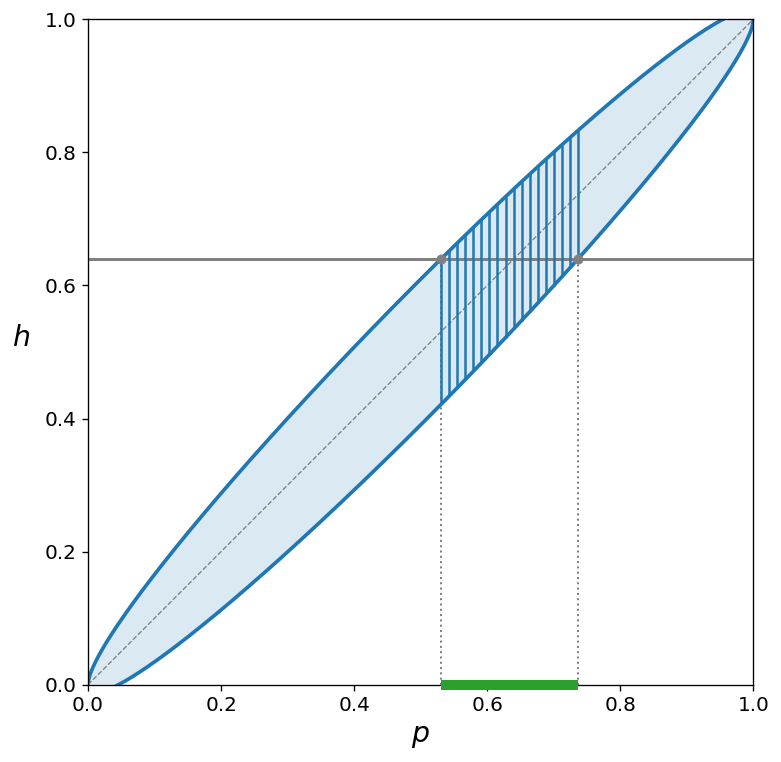

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 7.2))

ax.fill_between(
    p,
    np.clip(lower, 0.0, 1.0),
    np.clip(upper, 0.0, 1.0),
    alpha=0.16,
)
ax.plot(p, lower, linewidth=2.2, color="tab:blue")
ax.plot(p, upper, linewidth=2.2, color="tab:blue")
ax.plot(p, p, linestyle="--", linewidth=0.8, color="gray")

if cfg.show_vertical_intervals:
    selected_p = np.linspace(
        p_left,
        p_right,
        cfg.number_of_vertical_intervals,
    )
    selected_lower, selected_upper = prediction_bounds(selected_p)
    ax.vlines(
        selected_p,
        np.clip(selected_lower, 0.0, 1.0),
        np.clip(selected_upper, 0.0, 1.0),
        linewidth=1.5,
        color="tab:blue",
        zorder=3,
    )

ax.axhline(cfg.h0, linewidth=1.8, color="gray")
ax.scatter(
    [p_left, p_right],
    [cfg.h0, cfg.h0],
    s=25,
    color="gray",
    zorder=6,
)

if cfg.show_projection:
    ax.vlines(
        [p_left, p_right],
        ymin=0.0,
        ymax=cfg.h0,
        linestyles=":",
        linewidth=1.2,
        color="gray",
    )
    ax.plot(
        [p_left, p_right],
        [0.0, 0.0],
        linewidth=6.0,
        solid_capstyle="butt",
        clip_on=False,
        color="tab:green",
        zorder=7,
    )

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$p$", fontsize=17)
ax.set_ylabel(r"$h$", fontsize=17, rotation=0, labelpad=14)
ax.tick_params(labelsize=12)

if cfg.save_figure:
    output_dir = Path(cfg.output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        output_dir / "01_konfidenzellipse.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        output_dir / "01_konfidenzellipse.png",
        dpi=240,
        bbox_inches="tight",
    )

plt.show()


## Mögliche Veränderungen

Besonders ergiebig sind Variationen von $n$, $\gamma$ und $h_0$.
Über die beiden Schalter kann man die Konstruktion schrittweise
aufbauen.
